#### Implementing Simple Chatbot Using LangGraph

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages #Merges two lists of messages, updating existing messages by ID

In [3]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ad98c18a04', 'id': 'chatcmpl-D5sHzR5wVvbo7pNU7eo7qyhYWYPop', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c2daa-deb2-7c30-953b-259ffd0719de-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [7]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Venkey and i love play cricket")

AIMessage(content='<think>\nOkay, Venkey mentioned that he loves playing cricket. I should respond in a friendly and encouraging way. Maybe ask him about his favorite part of the game or what position he plays. Also, offer some tips if he\'s interested. Keep it positive and engaging.\n\nLet me check if there are any common cricket-related topics to discuss. Perhaps talk about popular players or recent matches. But since he just started, maybe stick to his personal experience first. Avoid making the response too long but leave room for him to expand on his interests.\n\nMake sure the tone is approachable and not too formal. Use emojis to keep it light. Maybe add a cricket-related emoji like 🏏. Also, correct any spelling or grammar issues in his message if needed. He wrote "i love play cricket" so it should be "I love playing cricket" for proper grammar. But maybe just acknowledge it without pointing it out unless he\'s open to it.\n\nAlright, putting it all together: Start with a greeti

#### We will Start With Creating Nodes

In [8]:
def superbot(state:State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

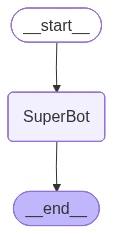

In [10]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [11]:
## Invocation

graph_builder.invoke({"messages":"Hi, My name is Venkey and I like to play cricket"})

{'messages': [HumanMessage(content='Hi, My name is Venkey and I like to play cricket', additional_kwargs={}, response_metadata={}, id='f334ca41-34a0-4d9a-86c3-9bad6216f051'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Venkey and mentioned they like to play cricket. I should acknowledge their greeting and express enthusiasm about cricket. It's good to ask a follow-up question to keep the conversation going. Maybe ask about their favorite team or if they play any specific position. Keep the tone friendly and approachable. Let them know I'm here to chat more about cricket or anything else they're interested in. Make sure the response is concise and welcoming.\n</think>\n\nHi Venkey! Nice to meet you. Cricket sounds like a fantastic choice—do you play any specific position or have a favorite team? I'd love to hear more about your cricket experiences or any exciting matches you've watched! 🏏", additional_kwargs={}, response_metadata={'token_usage': {'completion_to

#### Streaming the Responses

In [12]:
for event in graph_builder.stream({"messages":"Hello My name is Venkey"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user said Hello and introduced himself as Venkey. I should start by greeting him and asking how I can assist. Keep it friendly and open-ended. Maybe add an emoji to keep the tone light. Let him know I'm here to help with any questions or tasks he might have. Make sure the response is concise and welcoming.\n</think>\n\nHello, Venkey! 😊 How can I assist you today? Whether you have questions, need help with a task, or just want to chat, I'm here for you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 14, 'total_tokens': 125, 'completion_time': 0.20646835, 'completion_tokens_details': None, 'prompt_time': 0.000512683, 'prompt_tokens_details': None, 'queue_time': 0.006374515, 'total_time': 0.206981033}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_78ac7f3229', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, i